
================ ANALYSIS SUMMARY ================

Датасет: random_1000_3000.txt
Вершины: 1000
Рёбра:   3000
Лучшая точность:
  DEGREE_CENTRALITY (landmarks=16), avg_relative_error=0.224046
Самый быстрый ответ:
  SEQUENTIAL_INDEX (landmarks=4), avg_oracle_time_ms=0.0003846
Минимальная память:
  SEQUENTIAL_INDEX (landmarks=4), oracle_memory_bytes=32016

Датасет: random_2000_6000.txt
Вершины: 2000
Рёбра:   6000
Лучшая точность:
  DEGREE_CENTRALITY (landmarks=16), avg_relative_error=0.330465
Самый быстрый ответ:
  SEQUENTIAL_INDEX (landmarks=4), avg_oracle_time_ms=0.0005577
Минимальная память:
  SEQUENTIAL_INDEX (landmarks=4), oracle_memory_bytes=64016

Датасет: random_3000_9000.txt
Вершины: 3000
Рёбра:   9000
Лучшая точность:
  DEGREE_CENTRALITY (landmarks=16), avg_relative_error=0.343729
Самый быстрый ответ:
  DEGREE_CENTRALITY (landmarks=4), avg_oracle_time_ms=0.0005213
Минимальная память:
  SEQUENTIAL_INDEX (landmarks=4), oracle_memory_bytes=96016

Датасет: random_5000_15000.txt
Вер

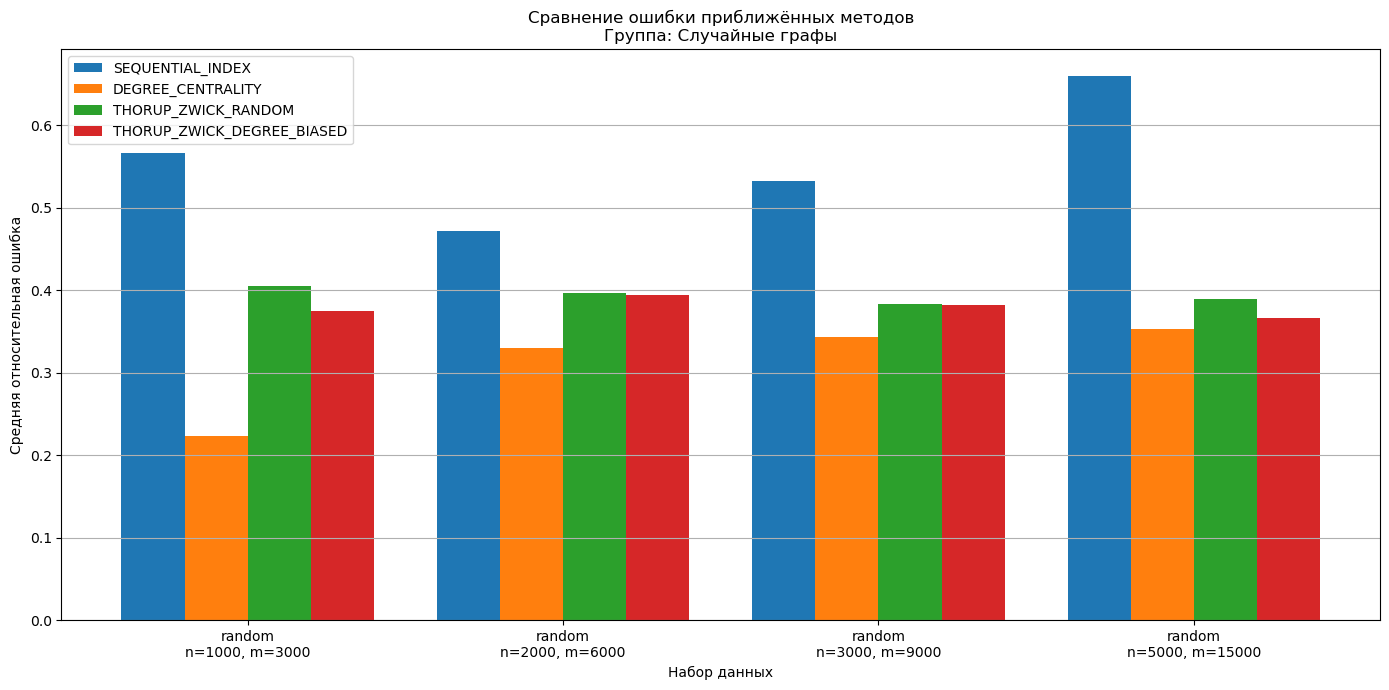

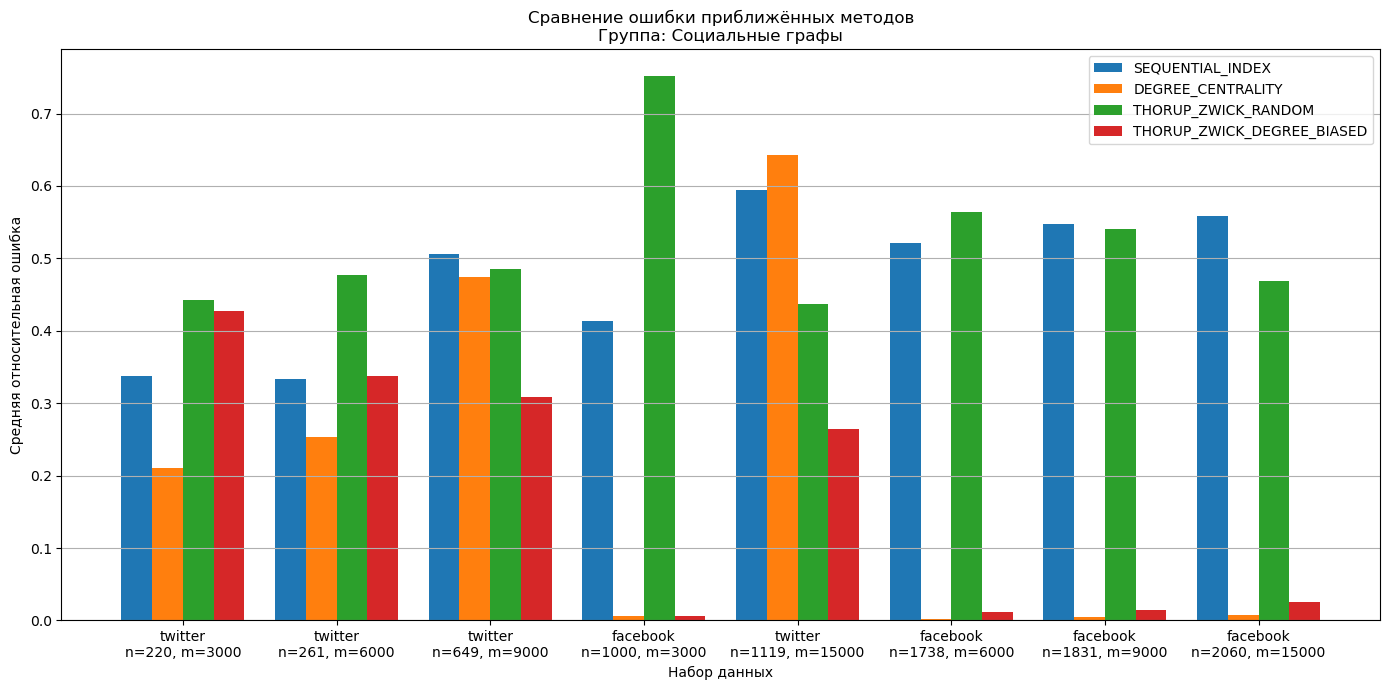

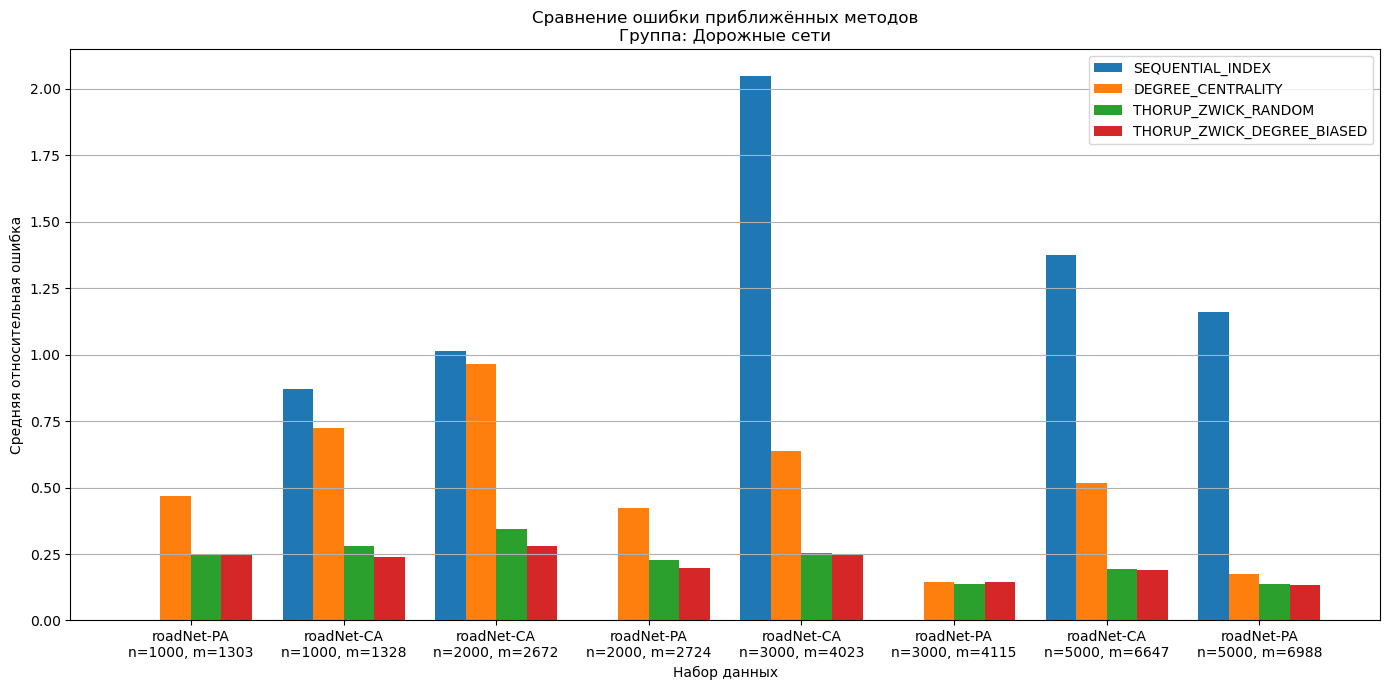

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


def short_dataset_name(name):
    return str(name).replace(".txt", "")


def prepare_data(filename):
    data = pd.read_csv(filename)

    data["dataset_short"] = data["dataset"].apply(short_dataset_name)

    data["method_param"] = (
        data["method"].astype(str)
        + "\n"
        + data["parameter_name"].astype(str)
        + "="
        + data["parameter_value"].astype(str)
    )

    data["memory_kb"] = data["oracle_memory_bytes"] / 1024.0

    return data


def get_dataset_type(dataset_name):
    """
    Определяет тип датасета по имени файла.
    """

    name = dataset_name.lower()

    if "random" in name:
        return "Случайные графы"

    if "facebook" in name or "twitter" in name:
        return "Социальные графы"

    if "roadnet" in name:
        return "Дорожные сети"

    return "Другие графы"


def make_dataset_label(row):
    """
    Подпись датасета с размером графа.
    """

    name = short_dataset_name(row["dataset"])

    parts = name.split("_")
    base_name = parts[0]

    if "roadNet-PA" in name:
        base_name = "roadNet-PA"
    elif "roadNet-CA" in name:
        base_name = "roadNet-CA"
    elif "facebook" in name:
        base_name = "facebook"
    elif "twitter" in name:
        base_name = "twitter"
    elif "random" in name:
        base_name = "random"

    return f"{base_name}\nn={int(row['vertices'])}, m={int(row['edges'])}"


def choose_best_rows_for_metric(data, metric):
    """
    Для каждого датасета и каждого метода выбирает лучший вариант параметра.

    Для ошибки, времени и памяти меньше = лучше.
    Например, если у landmark есть landmarks=4,8,16,
    берётся тот вариант, где выбранная метрика минимальна.
    """

    rows = []

    for dataset in data["dataset"].unique():
        dataset_data = data[data["dataset"] == dataset]

        for method in dataset_data["method"].unique():
            method_data = dataset_data[dataset_data["method"] == method]

            best_row = method_data.loc[method_data[metric].idxmin()]
            rows.append(best_row)

    return pd.DataFrame(rows)


def plot_grouped_bar_by_dataset_type(data, dataset_type, metric, ylabel, title):
    """
    Строит столбчатую диаграмму для одного типа графов:
    случайные, социальные или дорожные.

    По оси X — наборы данных с размерами.
    Цвета — разные методы.
    """

    data = data.copy()
    data["dataset_type"] = data["dataset"].apply(get_dataset_type)

    type_data = data[data["dataset_type"] == dataset_type].copy()

    if type_data.empty:
        print(f"Нет данных для группы: {dataset_type}")
        return

    best_data = choose_best_rows_for_metric(type_data, metric)

    # Сортируем по числу вершин, чтобы графы шли от меньших к большим
    best_data = best_data.sort_values(by=["vertices", "edges", "dataset"])

    datasets = best_data["dataset"].unique()
    methods = best_data["method"].unique()

    x = np.arange(len(datasets))
    width = 0.8 / len(methods)

    plt.figure(figsize=(14, 7))

    for method_index, method in enumerate(methods):
        values = []

        for dataset in datasets:
            row = best_data[
                (best_data["dataset"] == dataset) &
                (best_data["method"] == method)
            ]

            if row.empty:
                values.append(0)
            else:
                values.append(row.iloc[0][metric])

        offset = (method_index - len(methods) / 2) * width + width / 2

        plt.bar(
            x + offset,
            values,
            width,
            label=method
        )

    labels = []

    for dataset in datasets:
        row = best_data[best_data["dataset"] == dataset].iloc[0]
        labels.append(make_dataset_label(row))

    plt.xlabel("Набор данных")
    plt.ylabel(ylabel)
    plt.title(title + f"\nГруппа: {dataset_type}")
    plt.xticks(x, labels, rotation=0)
    plt.grid(axis="y")
    plt.legend()
    plt.tight_layout()

    plt.show()


def print_text_summary(data):
    print("\n================ ANALYSIS SUMMARY ================\n")

    for dataset in data["dataset"].unique():
        dataset_data = data[data["dataset"] == dataset]

        print(f"Датасет: {dataset}")
        print(f"Вершины: {dataset_data.iloc[0]['vertices']}")
        print(f"Рёбра:   {dataset_data.iloc[0]['edges']}")

        best_error = dataset_data.loc[
            dataset_data["avg_relative_error"].idxmin()
        ]

        best_speed = dataset_data.loc[
            dataset_data["avg_oracle_time_ms"].idxmin()
        ]

        best_memory = dataset_data.loc[
            dataset_data["oracle_memory_bytes"].idxmin()
        ]

        print("Лучшая точность:")
        print(
            f"  {best_error['method']} "
            f"({best_error['parameter_name']}={best_error['parameter_value']}), "
            f"avg_relative_error={best_error['avg_relative_error']}"
        )

        print("Самый быстрый ответ:")
        print(
            f"  {best_speed['method']} "
            f"({best_speed['parameter_name']}={best_speed['parameter_value']}), "
            f"avg_oracle_time_ms={best_speed['avg_oracle_time_ms']}"
        )

        print("Минимальная память:")
        print(
            f"  {best_memory['method']} "
            f"({best_memory['parameter_name']}={best_memory['parameter_value']}), "
            f"oracle_memory_bytes={best_memory['oracle_memory_bytes']}"
        )

        print()


def main():
    data = prepare_data("all_summary_results.csv")

    print_text_summary(data)

    plot_grouped_bar_by_dataset_type(
        data,
        "Случайные графы",
        "avg_relative_error",
        "Средняя относительная ошибка",
        "Сравнение ошибки приближённых методов"
    )

    plot_grouped_bar_by_dataset_type(
        data,
        "Социальные графы",
        "avg_relative_error",
        "Средняя относительная ошибка",
        "Сравнение ошибки приближённых методов"
    )

    plot_grouped_bar_by_dataset_type(
        data,
        "Дорожные сети",
        "avg_relative_error",
        "Средняя относительная ошибка",
        "Сравнение ошибки приближённых методов"
    )

main()

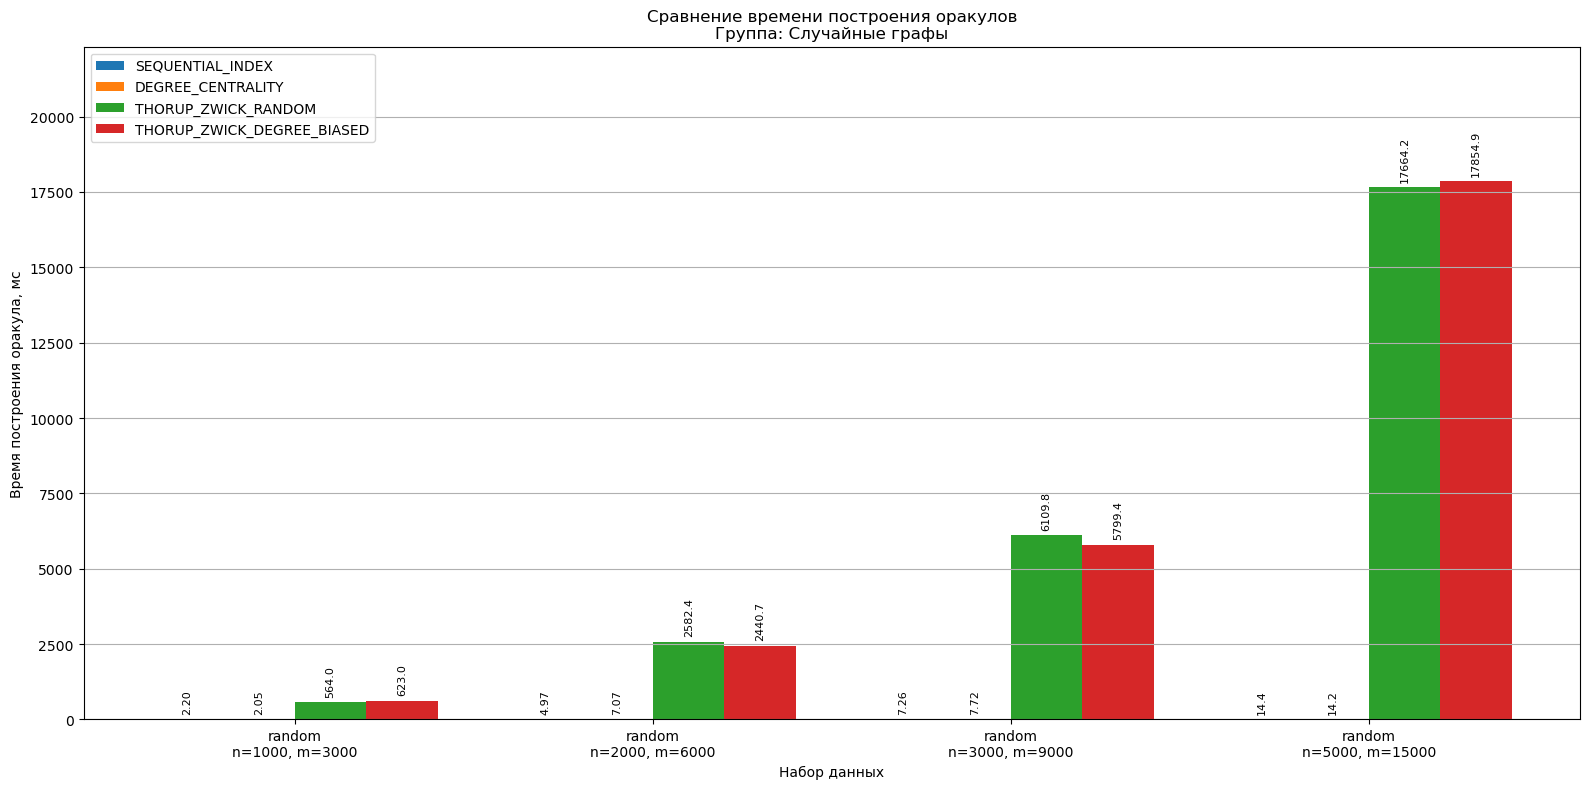

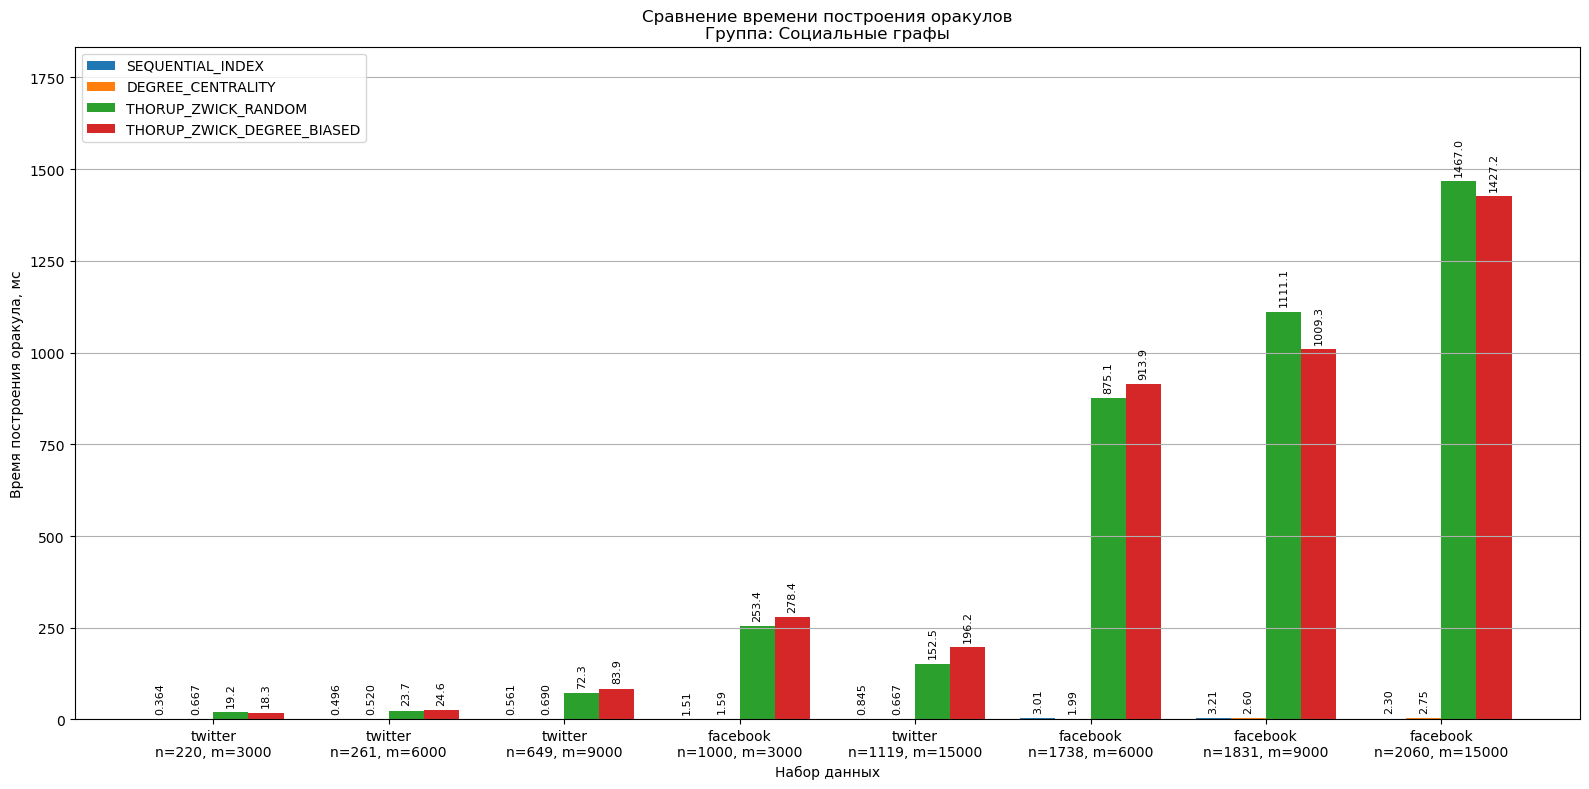

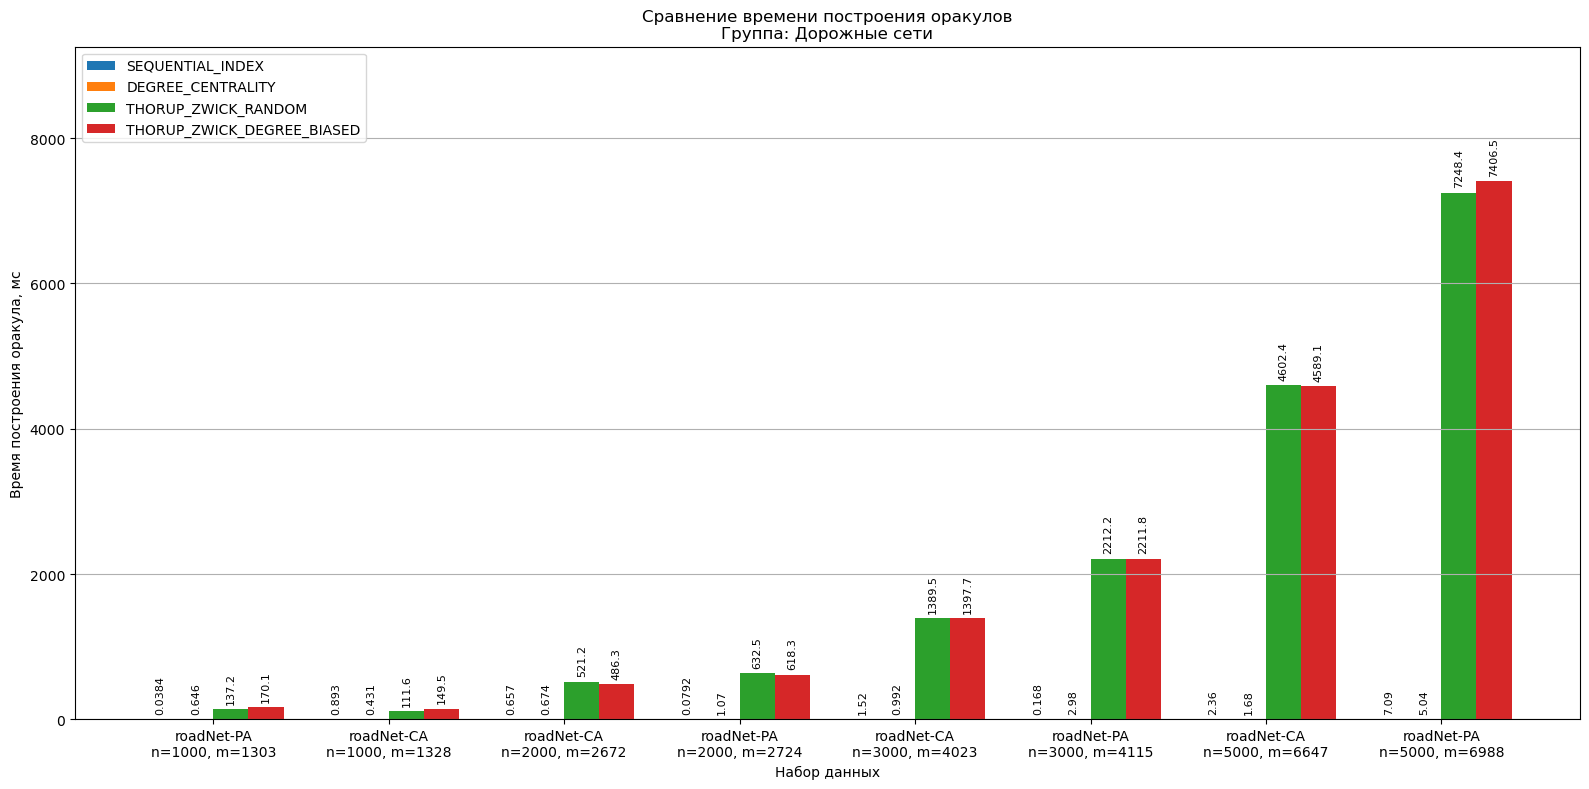

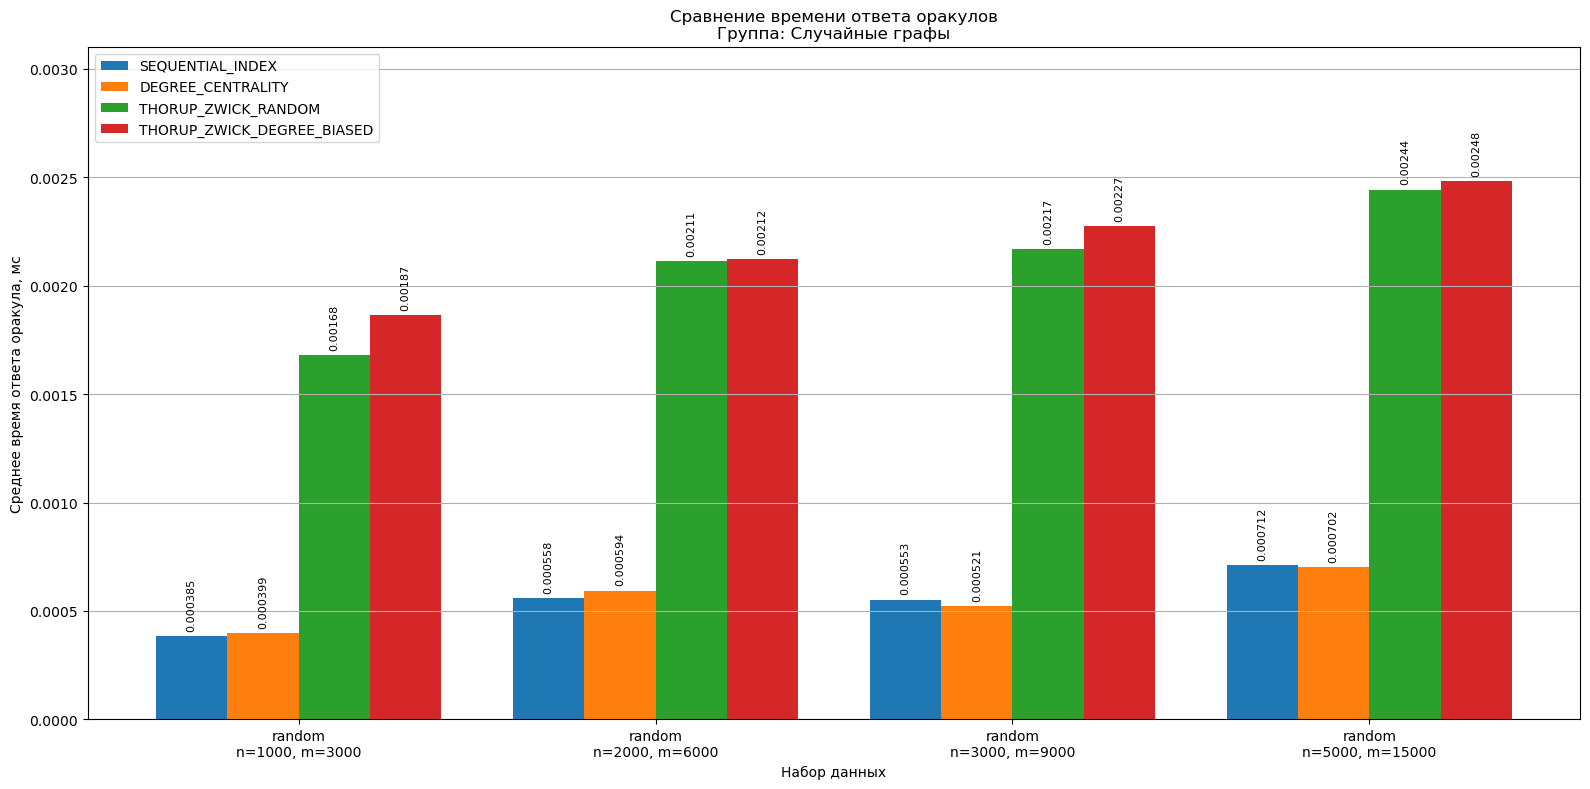

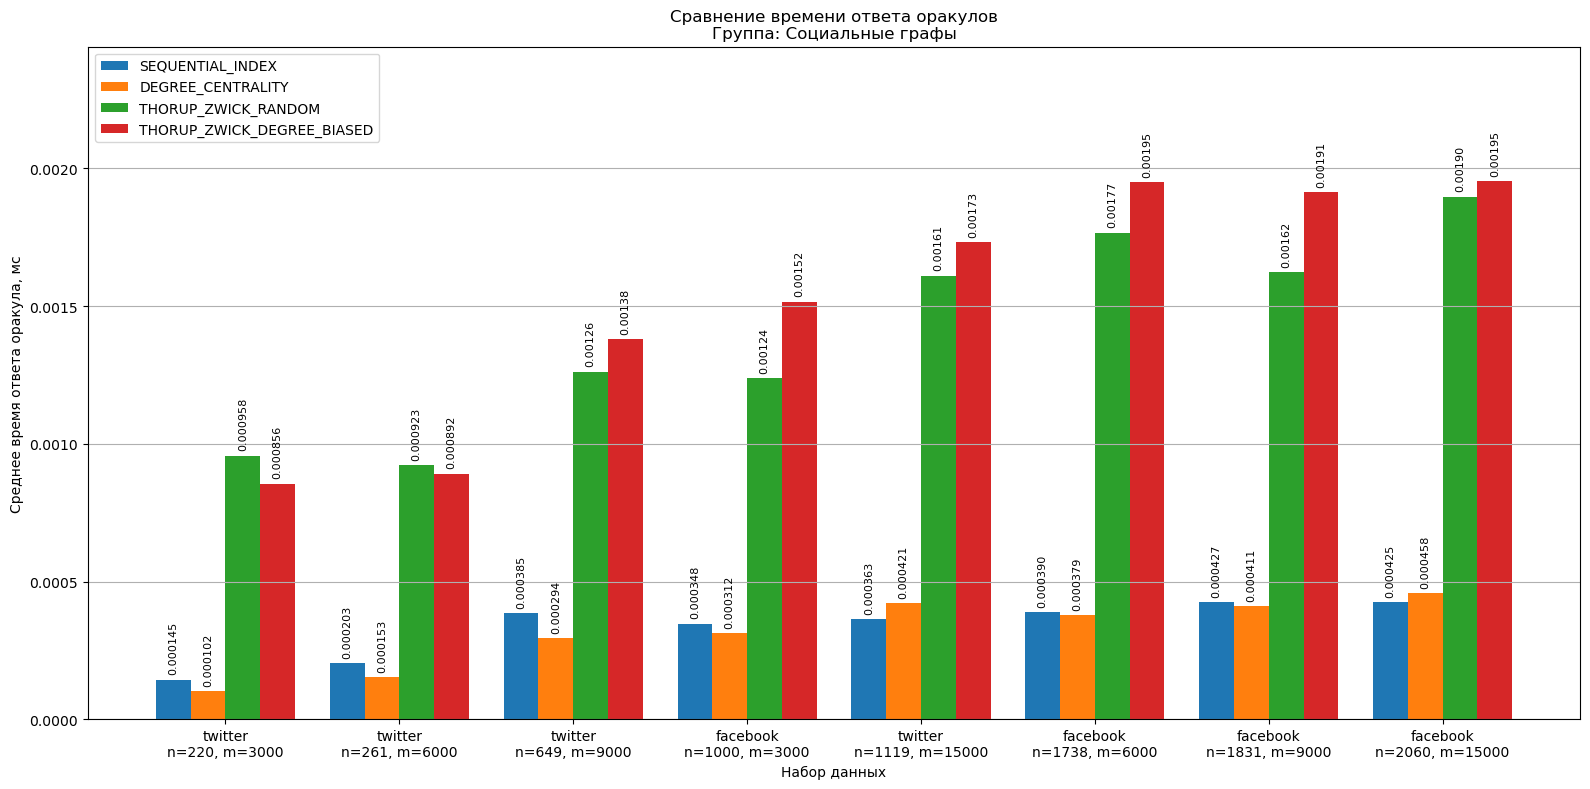

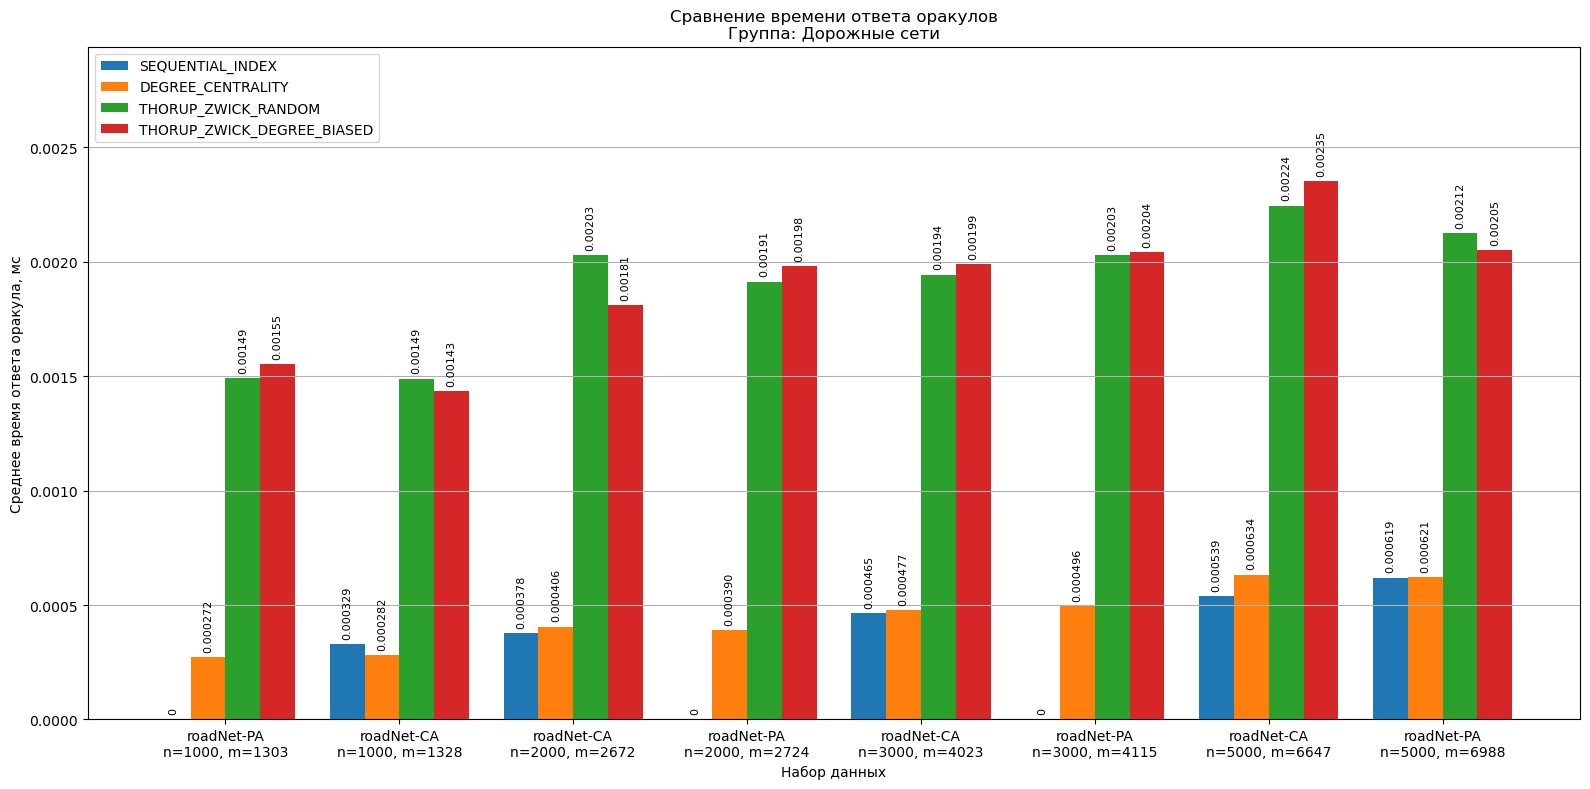

In [12]:
def short_dataset_name(name):
    return str(name).replace(".txt", "")


def prepare_data(filename):
    data = pd.read_csv(filename)

    data["dataset_short"] = data["dataset"].apply(short_dataset_name)

    data["method_param"] = (
        data["method"].astype(str)
        + "\n"
        + data["parameter_name"].astype(str)
        + "="
        + data["parameter_value"].astype(str)
    )

    data["memory_kb"] = data["oracle_memory_bytes"] / 1024.0

    return data


def get_dataset_type(dataset_name):
    """
    Определяет тип датасета по имени файла.
    """

    name = dataset_name.lower()

    if "random" in name:
        return "Случайные графы"

    if "facebook" in name or "twitter" in name:
        return "Социальные графы"

    if "roadnet" in name:
        return "Дорожные сети"

    return "Другие графы"


def make_dataset_label(row):
    """
    Подпись датасета с размером графа.
    """

    name = short_dataset_name(row["dataset"])

    if "roadNet-PA" in name:
        base_name = "roadNet-PA"
    elif "roadNet-CA" in name:
        base_name = "roadNet-CA"
    elif "facebook" in name:
        base_name = "facebook"
    elif "twitter" in name:
        base_name = "twitter"
    elif "random" in name:
        base_name = "random"
    else:
        base_name = name

    return f"{base_name}\nn={int(row['vertices'])}, m={int(row['edges'])}"


def choose_best_rows_for_metric(data, metric):
    """
    Для каждого датасета и каждого метода выбирает лучший вариант параметра.

    Для времени построения и времени ответа меньше = лучше.
    Поэтому берём строку с минимальным значением metric.
    """

    rows = []

    for dataset in data["dataset"].unique():
        dataset_data = data[data["dataset"] == dataset]

        for method in dataset_data["method"].unique():
            method_data = dataset_data[dataset_data["method"] == method]

            best_row = method_data.loc[method_data[metric].idxmin()]
            rows.append(best_row)

    return pd.DataFrame(rows)

def format_value(value):
    """
    Форматирует подписи над столбцами.
    Для маленьких значений показывает больше знаков.
    """

    if value == 0:
        return "0"

    if abs(value) < 0.001:
        return f"{value:.6f}"

    if abs(value) < 0.01:
        return f"{value:.5f}"

    if abs(value) < 0.1:
        return f"{value:.4f}"

    if abs(value) < 1:
        return f"{value:.3f}"

    if abs(value) < 10:
        return f"{value:.2f}"

    return f"{value:.1f}"


def plot_grouped_bar_by_dataset_type(data, dataset_type, metric, ylabel, title):
    """
    Строит столбчатую диаграмму для одного типа графов.

    По оси X — наборы данных с размерами.
    Цвета — разные методы.
    По оси Y — выбранная метрика.
    Над каждым столбцом выводится числовое значение.
    """

    data = data.copy()
    data["dataset_type"] = data["dataset"].apply(get_dataset_type)

    type_data = data[data["dataset_type"] == dataset_type].copy()

    if type_data.empty:
        print(f"Нет данных для группы: {dataset_type}")
        return

    best_data = choose_best_rows_for_metric(type_data, metric)

    best_data = best_data.sort_values(by=["vertices", "edges", "dataset"])

    datasets = best_data["dataset"].unique()
    methods = best_data["method"].unique()

    x = np.arange(len(datasets))
    width = 0.8 / len(methods)

    plt.figure(figsize=(16, 8))

    max_value = best_data[metric].max()

    for method_index, method in enumerate(methods):
        values = []

        for dataset in datasets:
            row = best_data[
                (best_data["dataset"] == dataset) &
                (best_data["method"] == method)
            ]

            if row.empty:
                values.append(0)
            else:
                values.append(row.iloc[0][metric])

        offset = (method_index - len(methods) / 2) * width + width / 2

        bars = plt.bar(
            x + offset,
            values,
            width,
            label=method
        )

        # Подписи над столбцами
        for bar, value in zip(bars, values):
            height = bar.get_height()

            # Небольшой отступ над столбцом
            text_offset = max_value * 0.01 if max_value > 0 else 0.001

            plt.text(
                bar.get_x() + bar.get_width() / 2,
                height + text_offset,
                format_value(value),
                ha="center",
                va="bottom",
                fontsize=8,
                rotation=90
            )

    labels = []

    for dataset in datasets:
        row = best_data[best_data["dataset"] == dataset].iloc[0]
        labels.append(make_dataset_label(row))

    plt.xlabel("Набор данных")
    plt.ylabel(ylabel)
    plt.title(title + f"\nГруппа: {dataset_type}")
    plt.xticks(x, labels, rotation=0)
    plt.grid(axis="y")
    plt.legend()

    # Делаем верхнюю границу чуть выше, чтобы подписи не обрезались
    if max_value > 0:
        plt.ylim(0, max_value * 1.25)

    plt.tight_layout()
    plt.show()

def main():
    data = prepare_data("all_summary_results.csv")

    dataset_types = [
        "Случайные графы",
        "Социальные графы",
        "Дорожные сети"
    ]

    for dataset_type in dataset_types:
        plot_grouped_bar_by_dataset_type(
            data,
            dataset_type,
            "oracle_build_time_ms",
            "Время построения оракула, мс",
            "Сравнение времени построения оракулов"
        )

    for dataset_type in dataset_types:
        plot_grouped_bar_by_dataset_type(
            data,
            dataset_type,
            "avg_oracle_time_ms",
            "Среднее время ответа оракула, мс",
            "Сравнение времени ответа оракулов"
        )
main()